## <span style="color:#1f497d; border-bottom: 2px solid #1f497d; padding-bottom: 5px;">Ejercicio 1: Evaluación de solicitud de crédito bancario</span>

### <span style="color:#c0504d;">Ficha PEAS</span>

* <b style="color:#4f81bd;">Percepción (S):</b> Ingreso mensual (número), monto solicitado (número), tiene historial moroso (booleano).
* <b style="color:#4f81bd;">Acciones (A):</b> Aprobar, aprobar con condiciones, rechazar.
* <b style="color:#4f81bd;">Entorno (E):</b> Sistema de evaluación financiera/crediticia del banco.
* <b style="color:#4f81bd;">Objetivo:</b> Otorgar créditos de forma segura, minimizando las pérdidas económicas por impago.
* <b style="color:#4f81bd;">Medida de desempeño (P):</b> Riesgo de impago minimizado, tasa de créditos rentables otorgados, dinero salvado de posibles morosos.
### <span style="color:#c0504d;">Justificación de las reglas</span>

<span style="color:#595959;">Las reglas priorizan la seguridad financiera del banco evaluando la capacidad de pago (relación monto/ingreso) y la confianza (historial). Si la relación supera el 50% ($0.5$), el riesgo es crítico y se rechaza. Si la relación es moderada ($0.3$ a $0.5$) sin mora, se aprueba con condiciones para proteger al banco. Una relación menor a $0.3$ sin mora es el perfil ideal y se aprueba directamente.</span>

In [3]:
### Código
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual
    
    if tiene_historial_moroso:
        if relacion >= 0.4:
            return "rechazar", f"riesgo muy alto: historial moroso y relacion monto/ingreso de {relacion:.2f}"
        else:
            return "aprobar con condiciones", f"monto moderado ({relacion:.2f}) pero con historial moroso, requiere garante"
    else:
        if relacion > 0.5:
            return "rechazar", f"endeudamiento excesivo: relacion de {relacion:.2f} supera el limite de 0.5"
        elif relacion >= 0.3:
            return "aprobar con condiciones", f"buen historial, pero endeudamiento medio-alto ({relacion:.2f}), ajustar tasa"
        else:
            return "aprobar", f"perfil optimo: sin mora y endeudamiento bajo ({relacion:.2f})"

### <span style="color:#c0504d;">Simulación y pruebas</span>


In [3]:
# Pruebas con 6 combinaciones (incluyendo casos limite)
casos = [
    (5000, 1000, False),  # 1. Optimo (relacion 0.2)
    (4000, 1600, False),  # 2. Borde (relacion 0.4 - condiciones)
    (3000, 1800, False),  # 3. Exceso sin mora (relacion 0.6 - rechazar)
    (6000, 2000, True),   # 4. Moderado con mora (relacion 0.33 - condiciones)
    (2000, 1000, True),   # 5. Exceso con mora (relacion 0.5 - rechazar)
    (5000, 1500, False)   # 6. Caso limite exacto (relacion 0.3 - entra a condiciones)
]

print("--- SIMULACIÓN DE AGENTE DE CRÉDITO ---")
for ingreso, monto, mora in casos:
    accion, motivo = agente_credito(ingreso, monto, mora)
    print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {mora}")
    print(f"-> ACCIÓN: {accion.upper()}")
    print(f"-> MOTIVO: {motivo}\n")

--- SIMULACIÓN DE AGENTE DE CRÉDITO ---
Ingreso: S/5000 | Monto: S/1000 | Moroso: False
-> ACCIÓN: APROBAR
-> MOTIVO: perfil optimo: sin mora y endeudamiento bajo (0.20)

Ingreso: S/4000 | Monto: S/1600 | Moroso: False
-> ACCIÓN: APROBAR CON CONDICIONES
-> MOTIVO: buen historial, pero endeudamiento medio-alto (0.40), ajustar tasa

Ingreso: S/3000 | Monto: S/1800 | Moroso: False
-> ACCIÓN: RECHAZAR
-> MOTIVO: endeudamiento excesivo: relacion de 0.60 supera el limite de 0.5

Ingreso: S/6000 | Monto: S/2000 | Moroso: True
-> ACCIÓN: APROBAR CON CONDICIONES
-> MOTIVO: monto moderado (0.33) pero con historial moroso, requiere garante

Ingreso: S/2000 | Monto: S/1000 | Moroso: True
-> ACCIÓN: RECHAZAR
-> MOTIVO: riesgo muy alto: historial moroso y relacion monto/ingreso de 0.50

Ingreso: S/5000 | Monto: S/1500 | Moroso: False
-> ACCIÓN: APROBAR CON CONDICIONES
-> MOTIVO: buen historial, pero endeudamiento medio-alto (0.30), ajustar tasa



### <span style="color:#c0504d;">Visualización</span>

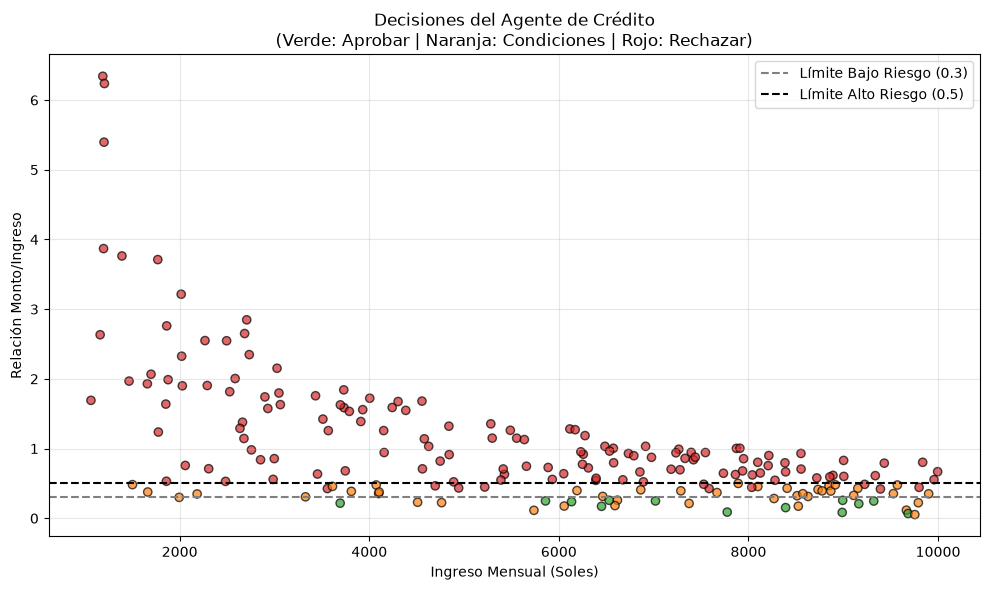

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generar 200 solicitudes aleatorias
np.random.seed(42) # Para que los resultados sean reproducibles
ingresos = np.random.randint(1000, 10000, 200)
montos = np.random.randint(500, 8000, 200)
historiales = np.random.choice([True, False], 200)

relaciones = montos / ingresos
colores = []

# Evaluar cada solicitud con nuestro agente
for ing, mon, mor in zip(ingresos, montos, historiales):
    accion, _ = agente_credito(ing, mon, mor)
    if accion == "aprobar":
        colores.append('#2ca02c') # Verde
    elif accion == "aprobar con condiciones":
        colores.append('#ff7f0e') # Naranja
    else:
        colores.append('#d62728') # Rojo

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(ingresos, relaciones, c=colores, alpha=0.7, edgecolors='k')
plt.title('Decisiones del Agente de Crédito\n(Verde: Aprobar | Naranja: Condiciones | Rojo: Rechazar)')
plt.xlabel('Ingreso Mensual (Soles)')
plt.ylabel('Relación Monto/Ingreso')

# Líneas de referencia
plt.axhline(y=0.3, color='gray', linestyle='--', label='Límite Bajo Riesgo (0.3)')
plt.axhline(y=0.5, color='black', linestyle='--', label='Límite Alto Riesgo (0.5)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()